In [1]:
import pandas as pd 
import numpy as np
import joblib
import time
import sklearn.metrics
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, precision_recall_fscore_support, recall_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier

## Dataset Prepare

In [2]:
def calculate_macro_tpr_fpr(voting_cm):
    num_classes = voting_cm.shape[0]
    tpr_list = []
    fpr_list = []

    for i in range(num_classes):
        TP = voting_cm[i, i]
        FN = np.sum(voting_cm[i, :]) - TP
        FP = np.sum(voting_cm[:, i]) - TP
        TN = np.sum(voting_cm) - (TP + FN + FP)

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    macro_tpr = np.mean(tpr_list)
    macro_fpr = np.mean(fpr_list)

    return macro_tpr, macro_fpr

# Load models

In [3]:
test = pd.read_csv('./DS/test_shap_66.csv')

X_test = test.drop(['Label'], axis=1)
y_test = test['Label']

In [4]:
# --- Load models ---
xgb_model = XGBClassifier()
xgb_model = joblib.load('./models/framework_xgb_TVAE.pkl')

cat_model = CatBoostClassifier()
cat_model = joblib.load('./models/framework_cat_TVAE.pkl')

rf_model = RandomForestClassifier()
rf_model = joblib.load('./models/framework_rf_TVAE.pkl')

et_model = ExtraTreesClassifier()
et_model = joblib.load('./models/framework_et_TVAE.pkl')

lgbm_model = LGBMClassifier()
lgbm_model = joblib.load('./models/framework_lgbm_TVAE.pkl')

# --- Predict proba ---
xgb_preds = xgb_model.predict_proba(X_test)
cat_preds = cat_model.predict_proba(X_test)
rf_preds  = rf_model.predict_proba(X_test)
et_preds  = et_model.predict_proba(X_test)
lgbm_preds = lgbm_model.predict_proba(X_test)

# --- Predict labels ---
xgb_prediction = xgb_model.predict(X_test)
cat_prediction = cat_model.predict(X_test)
rf_prediction  = rf_model.predict(X_test)
et_prediction  = et_model.predict(X_test)
lgbm_prediction = lgbm_model.predict(X_test)

# --- Accuracy ---
xgb_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=xgb_prediction)
cat_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=cat_prediction)
rf_acc  = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=rf_prediction)
et_acc  = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=et_prediction)
lgbm_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=lgbm_prediction)

print("XGBoost Accuracy:", xgb_acc)
print("CatBoost Accuracy:", cat_acc)
print("RandomForest Accuracy:", rf_acc)
print("ExtraTrees Accuracy:", et_acc)
print("LightGBM Accuracy:", lgbm_acc)

# --- Macro-F1 ---
print("XGBoost Macro-F1:", f1_score(y_true=y_test, y_pred=xgb_prediction, average="macro"))
print("CatBoost Macro-F1:", f1_score(y_true=y_test, y_pred=cat_prediction, average="macro"))
print("RandomForest Macro-F1:", f1_score(y_true=y_test, y_pred=rf_prediction, average="macro"))
print("ExtraTrees Macro-F1:", f1_score(y_true=y_test, y_pred=et_prediction, average="macro"))
print("LightGBM Macro-F1:", f1_score(y_true=y_test, y_pred=lgbm_prediction, average="macro"))

XGBoost Accuracy: 0.8668639053254438
CatBoost Accuracy: 0.8708086785009862
RandomForest Accuracy: 0.8673570019723866
ExtraTrees Accuracy: 0.866370808678501
LightGBM Accuracy: 0.8574950690335306
XGBoost Macro-F1: 0.8626816745525642
CatBoost Macro-F1: 0.8681410609384864
RandomForest Macro-F1: 0.8646349705114257
ExtraTrees Macro-F1: 0.8630207588759967
LightGBM Macro-F1: 0.852131382814227


In [5]:
train = pd.read_csv('./DS/train_tvae.csv')

X_train = train.drop(['Label'], axis=1)
y_train = train['Label']

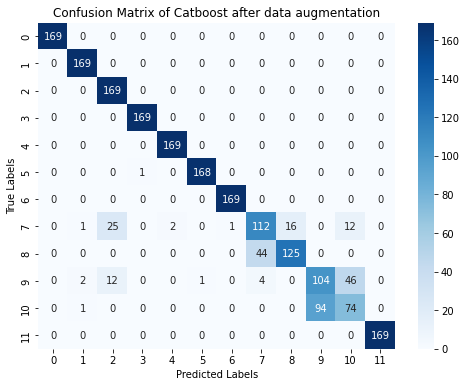

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=cat_prediction)
plt.figure(figsize=(8, 6))
sns.heatmap(cat_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of Catboost after data augmentation')
plt.show()

# LSTM

In [7]:
# ============================
# LSTM cho Tabular — IEC/ICS preset — KHÔNG focus lớp nào
#  - Stratified split (VAL 15%)
#  - StandardScaler
#  - DataLoader (shuffle, không sampler/boost)
#  - LSTM (2 tầng, BiLSTM) + AttnPooling
#  - Mixup công bằng cho mọi lớp
#  - EMA (float-only) device-safe
#  - Early-stopping theo Macro-F1 (VAL)
#  - Đánh giá: Acc, Macro-F1, per-class metrics
# ============================
import math, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, precision_recall_fscore_support

# ----- Device & seed -----
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42); np.random.seed(42)

# ===== Dữ liệu =====
assert "Label" in train.columns and "Label" in test.columns, "Thiếu cột Label trong train/test"
X_full = train.drop(columns=["Label"]).values
y_full = train["Label"].astype(int).values
X_test = test.drop(columns=["Label"]).values
y_test = test["Label"].astype(int).values

num_classes  = int(max(y_full.max(), y_test.max())) + 1
num_features = X_full.shape[1]

# ===== 1) Stratified split: train_in / val (15%) =====
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(sss.split(X_full, y_full))
X_tr_in, y_tr_in = X_full[train_idx], y_full[train_idx]
X_val,   y_val   = X_full[val_idx],   y_full[val_idx]

# ===== 2) Scaler =====
scaler = StandardScaler()
X_tr_in_sc = scaler.fit_transform(X_tr_in)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# ===== 3) DataLoaders =====
Xtr_t = torch.tensor(X_tr_in_sc, dtype=torch.float32)
ytr_t = torch.tensor(y_tr_in,    dtype=torch.long)
Xva_t = torch.tensor(X_val_sc,   dtype=torch.float32)
yva_t = torch.tensor(y_val,      dtype=torch.long)
Xte_t = torch.tensor(X_test_sc,  dtype=torch.float32)
yte_t = torch.tensor(y_test,     dtype=torch.long)

batch_size = 2048
train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True,  pin_memory=True)
val_loader   = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=4096, shuffle=False, pin_memory=True)
test_loader  = DataLoader(TensorDataset(Xte_t, yte_t), batch_size=4096, shuffle=False, pin_memory=True)

# ===== 4) Tiện ích: chia feature thành "chuỗi" =====
# Ta coi features như một chuỗi gồm S steps, mỗi step có input_size = STEP_DIM
# (pad 0 nếu F không chia hết)
STEP_DIM = 16  # bạn có thể thử 8/16/32
def as_sequence(x_np: np.ndarray, step_dim: int = STEP_DIM):
    F = x_np.shape[1]
    S = int(np.ceil(F / step_dim))
    pad = S * step_dim - F
    if pad > 0:
        x_np = np.pad(x_np, ((0,0),(0,pad)), mode="constant")
    return x_np.reshape(-1, S, step_dim), S

# ===== 5) Mô hình LSTM + AttnPooling =====
class AttnPool(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.proj = nn.Linear(d, 1)
    def forward(self, H):        # H: [B,S,D]
        score = self.proj(H).squeeze(-1)           # [B,S]
        w = torch.softmax(score, dim=1)            # [B,S]
        pooled = (H * w.unsqueeze(-1)).sum(1)      # [B,D]
        return pooled

class LSTMTabular(nn.Module):
    def __init__(self, step_dim, hidden=256, layers=2, n_classes=10, dropout=0.2, bidir=True):
        super().__init__()
        self.step_dim = step_dim
        self.in_norm  = nn.LayerNorm(step_dim)
        self.lstm = nn.LSTM(
            input_size=step_dim,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True,
            dropout=dropout if layers > 1 else 0.0,
            bidirectional=bidir
        )
        d_out = hidden * (2 if bidir else 1)
        self.pool = AttnPool(d_out)
        self.head = nn.Sequential(
            nn.Linear(d_out, d_out//2), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(d_out//2, n_classes)
        )
    def forward(self, x):                       # x: [B, F]
        B, F = x.shape
        S = int(math.ceil(F / self.step_dim))
        pad = S * self.step_dim - F
        if pad > 0:
            x = torch.nn.functional.pad(x, (0, pad), value=0.0)
        x = x.view(B, S, self.step_dim)         # [B,S,step_dim]
        x = self.in_norm(x)
        H, _ = self.lstm(x)                     # [B,S,D]
        z = self.pool(H)                        # [B,D]
        return self.head(z)                     # [B,C]

model = LSTMTabular(step_dim=STEP_DIM, hidden=256, layers=2, n_classes=num_classes, dropout=0.15, bidir=True).to(device)

# ===== 6) Loss/optim/scheduler + mixup (công bằng) =====
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=2e-4)

total_epochs = 120
warmup_epochs = 19
steps_per_epoch = max(1, len(train_loader))
def lr_lambda(step):
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps  = total_epochs * steps_per_epoch
    if step < warmup_steps: return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, (total_steps - warmup_steps))
    return 0.5 * (1 + math.cos(math.pi * progress))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def mixup_pair(x, y, alpha=0.10):
    if alpha <= 0: return x, y, 1.0, None
    lam  = np.random.beta(alpha, alpha)
    perm = torch.randperm(x.size(0), device=x.device)
    x_m  = lam * x + (1 - lam) * x[perm]
    y_perm = y[perm]
    return x_m, y, lam, y_perm

# ===== 7) EMA (float-only) — device-safe =====
ema_decay = 0.995
ema_state = {}
for k, v in model.state_dict().items():
    if v.is_floating_point():
        ema_state[k] = v.detach().clone().to(device=v.device, dtype=v.dtype)

def ema_update(model, ema_state, decay: float):
    with torch.no_grad():
        for k, v in model.state_dict().items():
            if not v.is_floating_point(): continue
            if (ema_state[k].device != v.device) or (ema_state[k].dtype != v.dtype):
                ema_state[k] = ema_state[k].to(device=v.device, dtype=v.dtype)
            ema_state[k].mul_((decay)).add_(v.detach(), alpha=1.0 - decay)

def load_ema_state(model, ema_state):
    current = model.state_dict(); merged = {}
    for k, v in current.items():
        merged[k] = ema_state.get(k, v).to(device=v.device, dtype=v.dtype)
    model.load_state_dict(merged, strict=True)

# ===== 8) Train + Early-stopping theo Macro-F1 (VAL) =====
best_macro_f1, best_ema_snapshot, wait, patience = -1.0, None, 0, 20
global_step = 0

for epoch in range(total_epochs):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        xb_m, ya, lam, yb_ = mixup_pair(xb, yb, alpha=0.10)
        logits = model(xb_m)
        loss = lam * criterion(logits, ya) + (1 - lam) * criterion(logits, yb_) if yb_ is not None else criterion(logits, ya)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 3.0)
        optimizer.step(); scheduler.step()
        ema_update(model, ema_state, ema_decay)
        global_step += 1

    # Eval VAL với EMA
    saved_live = {k: v.detach().clone() for k, v in model.state_dict().items()}
    load_ema_state(model, ema_state)
    model.eval()
    with torch.no_grad():
        logits_val = []
        for xb, _ in val_loader:
            logits_val.append(model(xb.to(device)).cpu())
        logits_val = torch.cat(logits_val, 0).numpy()
    pred_val = logits_val.argmax(1)
    macro_f1 = f1_score(y_val, pred_val, average='macro', zero_division=0)

    if macro_f1 > best_macro_f1:
        best_macro_f1, wait = macro_f1, 0
        best_ema_snapshot = {k: v.detach().cpu().clone() for k, v in ema_state.items()}
    else:
        wait += 1

    model.load_state_dict(saved_live, strict=True)
    if wait >= patience:
        print(f"[Early-stop] epoch {epoch+1} | best VAL Macro-F1 = {best_macro_f1:.4f}")
        break

# Nạp EMA tốt nhất
if best_ema_snapshot is not None:
    ema_state = {k: t.clone().to(device) for k, t in best_ema_snapshot.items()}
    load_ema_state(model, ema_state)
model.eval()

# ===== 9) SUY LUẬN TEST =====
with torch.no_grad():
    logits_test = []
    for xb, _ in test_loader:
        logits_test.append(model(xb.to(device)).cpu())
    logits_test = torch.cat(logits_test, 0).numpy()

y_pred = logits_test.argmax(1)

# ===== 10) Đánh giá =====
acc = accuracy_score(y_test, y_pred)
macro_f1_all = f1_score(y_test, y_pred, average='macro', zero_division=0)

cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))
print(f"\nLSTM-Tabular — Acc: {acc:.4f} | Macro-F1(all): {macro_f1_all:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

labels_arr = np.arange(num_classes)
prec, rec, f1c, support = precision_recall_fscore_support(
    y_test, y_pred, labels=labels_arr, zero_division=0
)

# FPR per class
fpr_per_class = []
for i in labels_arr:
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)
    fpr_i = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    fpr_per_class.append(fpr_i)

macro_precision = float(np.mean(prec))
macro_recall    = float(np.mean(rec))
macro_fpr       = float(np.mean(fpr_per_class))

print("\n==== Macro metrics (all classes) ====")
print(f"Macro-Precision: {macro_precision:.4f}")
print(f"Macro-Recall/TPR: {macro_recall:.4f}")
print(f"Macro-FPR: {macro_fpr:.4f}")

per_class_df = pd.DataFrame({
    "class": labels_arr,
    "precision": prec,
    "recall_TPR": rec,
    "f1": f1c,
    "FPR": fpr_per_class,
    "support": support,
}).round(4)
print("\n==== Per-class metrics (all classes) ====")
print(per_class_df)


LSTM-Tabular — Acc: 0.6815 | Macro-F1(all): 0.6668

Classification report:
              precision    recall  f1-score   support

           0     0.9826    1.0000    0.9912       169
           1     0.8140    0.8284    0.8211       169
           2     0.7931    0.6805    0.7325       169
           3     0.2500    0.0888    0.1310       169
           4     0.4028    0.3432    0.3706       169
           5     0.6471    0.8462    0.7333       169
           6     0.4545    0.6805    0.5450       169
           7     0.6043    0.8402    0.7030       169
           8     0.8207    0.7041    0.7580       169
           9     0.6076    0.5680    0.5872       169
          10     0.6624    0.6154    0.6380       169
          11     1.0000    0.9822    0.9910       169

    accuracy                         0.6815      2028
   macro avg     0.6699    0.6815    0.6668      2028
weighted avg     0.6699    0.6815    0.6668      2028


==== Macro metrics (all classes) ====
Macro-Precision: 0

In [8]:
def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

# Xác suất dự đoán cho LSTM
p_test_lstm = softmax_np(logits_test)   # logits_test là numpy array từ bước suy luận LSTM
lstm_preds = p_test_lstm
LSTMprediction = y_pred               # y_pred đã lấy từ argmax của logits_test

LSTM_acc = accuracy_score(y_test, LSTMprediction)
LSTM_f1 = f1_score(y_test, LSTMprediction, average="macro", zero_division=0)
LSTM_precision = sklearn.metrics.precision_score(y_true=y_test, y_pred=LSTMprediction, average='macro', zero_division=0)
LSTM_recall = sklearn.metrics.recall_score(y_true=y_test, y_pred=LSTMprediction, average='macro', zero_division=0)
LSTM_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=LSTMprediction)

print("LSTM report:")
print("LSTM Accuracy:", LSTM_acc)
print("LSTM Precision:", LSTM_precision)
print("LSTM F1:", LSTM_f1)
print("LSTM Recall:", LSTM_recall)
print("LSTM CM:\n", LSTM_cm)
LSTM_tpr, LSTM_fpr = calculate_macro_tpr_fpr(LSTM_cm)
print(f'LSTM Macro-average TPR: {LSTM_tpr}')
print(f'LSTM Macro-average FPR: {LSTM_fpr}')
try:
    print("[LSTM] AUC (macro, OVR):", roc_auc_score(y_test, lstm_preds, multi_class='ovr', average='macro'))
except Exception as e:
    print("[LSTM] AUC không tính được:", e)

LSTM report:
LSTM Accuracy: 0.6814595660749507
LSTM Precision: 0.669913118769275
LSTM F1: 0.6668282372720801
LSTM Recall: 0.6814595660749507
LSTM CM:
 [[169   0   0   0   0   0   0   0   0   0   0   0]
 [  0 140  29   0   0   0   0   0   0   0   0   0]
 [  0  31 115   0   0   0   1  22   0   0   0   0]
 [  0   0   0  15  49  36  69   0   0   0   0   0]
 [  0   1   0  24  58  22  64   0   0   0   0   0]
 [  0   0   0  16   8 143   2   0   0   0   0   0]
 [  0   0   0   5  29  20 115   0   0   0   0   0]
 [  0   0   1   0   0   0   0 142  26   0   0   0]
 [  0   0   0   0   0   0   0  50 119   0   0   0]
 [  0   0   0   0   0   0   2  18   0  96  53   0]
 [  0   0   0   0   0   0   0   3   0  62 104   0]
 [  3   0   0   0   0   0   0   0   0   0   0 166]]
LSTM Macro-average TPR: 0.6814595660749507
LSTM Macro-average FPR: 0.028958221265913575
[LSTM] AUC không tính được: name 'roc_auc_score' is not defined


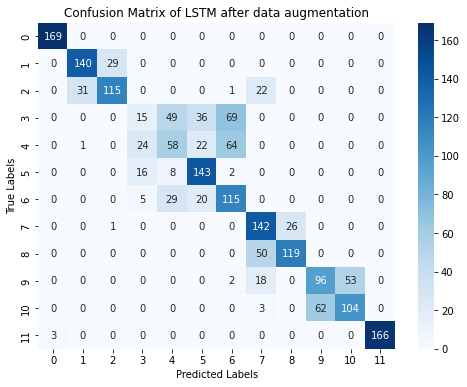

In [9]:
lstm_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=LSTMprediction)
plt.figure(figsize=(8, 6))
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of LSTM after data augmentation')
plt.show()

# DNN

In [10]:
# ============================
# DNN Tabular (MLP) — Neutral (no class focus) — Optimize overall Macro-F1
#  - Balanced sampler (inverse-frequency), no class boost
#  - Mixup (non-selective)
#  - EMA device-safe
#  - Early-stop theo Macro-F1 (VAL)
#  - Temperature scaling + multi-class logit-bias (grid) tối ưu Macro-F1 (VAL)
# ============================
import math, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, precision_recall_fscore_support

# ----- Device & seed -----
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42); np.random.seed(42)

# ===== Dữ liệu =====
assert "Label" in train.columns and "Label" in test.columns
X_full = train.drop(columns=["Label"]).values
y_full = train["Label"].astype(int).values
X_test = test.drop(columns=["Label"]).values
y_test = test["Label"].astype(int).values

num_classes  = int(max(y_full.max(), y_test.max())) + 1
num_features = X_full.shape[1]
labels_arr   = np.arange(num_classes)

# ===== 1) Stratified split: train_in / val (15%) =====
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(sss.split(X_full, y_full))
X_tr_in, y_tr_in = X_full[train_idx], y_full[train_idx]
X_val,   y_val   = X_full[val_idx],   y_full[val_idx]

# ===== 2) Scaler =====
scaler = StandardScaler()
X_tr_in_sc = scaler.fit_transform(X_tr_in)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# ===== 3) Sampler cân bằng (không boost lớp nào) =====
counts = np.bincount(y_tr_in, minlength=num_classes).astype(np.float32)
inv_freq = counts.sum() / (counts + 1e-9); inv_freq /= inv_freq.mean()
sample_w = inv_freq[y_tr_in]
sampler  = WeightedRandomSampler(weights=sample_w, num_samples=len(sample_w), replacement=True)

# ===== 4) DataLoaders =====
Xtr_t = torch.tensor(X_tr_in_sc, dtype=torch.float32)
ytr_t = torch.tensor(y_tr_in,    dtype=torch.long)
Xva_t = torch.tensor(X_val_sc,   dtype=torch.float32)
yva_t = torch.tensor(y_val,      dtype=torch.long)
Xte_t = torch.tensor(X_test_sc,  dtype=torch.float32)
yte_t = torch.tensor(y_test,     dtype=torch.long)

batch_size = 2048
train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, sampler=sampler, pin_memory=True)
val_loader   = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=4096, shuffle=False, pin_memory=True)
test_loader  = DataLoader(TensorDataset(Xte_t, yte_t), batch_size=4096, shuffle=False, pin_memory=True)

# ===== 5) Mô hình: DNN (MLP) =====
class DNN(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        W = 512
        self.net = nn.Sequential(
            nn.Linear(in_dim, W),      nn.BatchNorm1d(W),      nn.ReLU(), nn.Dropout(0.30),
            nn.Linear(W, W),           nn.BatchNorm1d(W),      nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(W, W//2),        nn.BatchNorm1d(W//2),   nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(W//2, W//4),     nn.BatchNorm1d(W//4),   nn.ReLU(), nn.Dropout(0.15),
        )
        self.head = nn.Linear(W//4, n_classes)
    def forward(self, x):
        return self.head(self.net(x))

model = DNN(num_features, num_classes).to(device)

# ===== 6) Loss/optim/scheduler + mixup =====
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=2e-4)

total_epochs = 120
warmup_epochs = 8
steps_per_epoch = max(1, len(train_loader))
def lr_lambda(step):
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps  = total_epochs * steps_per_epoch
    if step < warmup_steps: return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, (total_steps - warmup_steps))
    return 0.5 * (1 + math.cos(math.pi * progress))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def mixup(x, y, alpha=0.10):
    if alpha <= 0: return x, y, 1.0, None
    lam  = np.random.beta(alpha, alpha)
    perm = torch.randperm(x.size(0), device=x.device)
    x_m  = lam * x + (1 - lam) * x[perm]
    y_perm = y[perm]
    return x_m, y, lam, y_perm

# ===== 7) EMA (float-only) — device-safe =====
ema_decay = 0.995
ema_state = {}
for k, v in model.state_dict().items():
    if v.is_floating_point():
        ema_state[k] = v.detach().clone().to(device=v.device, dtype=v.dtype)

def ema_update(model, ema_state, decay: float):
    with torch.no_grad():
        for k, v in model.state_dict().items():
            if not v.is_floating_point(): continue
            if (ema_state[k].device != v.device) or (ema_state[k].dtype != v.dtype):
                ema_state[k] = ema_state[k].to(device=v.device, dtype=v.dtype)
            ema_state[k].mul_(decay).add_(v.detach(), alpha=1.0 - decay)

def load_ema_state(model, ema_state):
    current = model.state_dict(); merged = {}
    for k, v in current.items():
        merged[k] = ema_state.get(k, v).to(device=v.device, dtype=v.dtype)
    model.load_state_dict(merged, strict=True)

# ===== 8) Train + Early-stopping theo Macro-F1 (VAL) =====
best_macro_f1, best_ema_snapshot, wait, patience = -1.0, None, 0, 20
global_step = 0

for epoch in range(total_epochs):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        xb_m, ya, lam, yb_ = mixup(xb, yb, alpha=0.10)
        logits = model(xb_m)
        loss = lam * criterion(logits, ya) + (1 - lam) * criterion(logits, yb_) if yb_ is not None else criterion(logits, ya)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 3.0)
        optimizer.step(); scheduler.step()
        ema_update(model, ema_state, ema_decay)
        global_step += 1

    # Eval VAL với EMA
    saved_live = {k: v.detach().clone() for k, v in model.state_dict().items()}
    load_ema_state(model, ema_state)
    model.eval()
    with torch.no_grad():
        logits_val = []
        for xb, _ in val_loader:
            logits_val.append(model(xb.to(device)).cpu())
        logits_val = torch.cat(logits_val, 0).numpy()
    pred_val = logits_val.argmax(1)

    macro_f1 = f1_score(y_val, pred_val, average='macro', zero_division=0)
    if macro_f1 > best_macro_f1:
        best_macro_f1, wait = macro_f1, 0
        best_ema_snapshot = {k: v.detach().cpu().clone() for k, v in ema_state.items()}
    else:
        wait += 1

    model.load_state_dict(saved_live, strict=True)
    if wait >= patience:
        print(f"[Early-stop] epoch {epoch+1} | best VAL Macro-F1 = {best_macro_f1:.4f}")
        break

# Nạp EMA tốt nhất
if best_ema_snapshot is not None:
    ema_state = {k: t.clone().to(device) for k, t in best_ema_snapshot.items()}
    load_ema_state(model, ema_state)
model.eval()

# ===== 9) Calibration: Temperature scaling + multi-class logit-bias (VAL) =====
def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z); return e / e.sum(axis=1, keepdims=True)

with torch.no_grad():
    logits_val = []
    for xb, _ in val_loader:
        logits_val.append(model(xb.to(device)).cpu())
    logits_val = torch.cat(logits_val, 0).numpy()
    logits_test = []
    for xb, _ in test_loader:
        logits_test.append(model(xb.to(device)).cpu())
    logits_test = torch.cat(logits_test, 0).numpy()

# Grid nhỏ cho T và bias: bias áp cho từng lớp cùng một biên độ (đơn giản, hiệu quả)
T_candidates   = np.arange(0.5, 3.05, 0.1)
bias_levels    = np.arange(-0.5, 0.55, 0.1)  # b cộng vào logit mỗi lớp (cùng mức)
best_T, best_b, best_val_macro = 1.0, 0.0, -1.0

for T in T_candidates:
    logits_val_T = logits_val / T
    for b in bias_levels:
        logits_b = logits_val_T + b  # cùng mức cho mọi lớp (tránh thiên vị lớp riêng lẻ)
        p_val = softmax_np(logits_b)
        pred = p_val.argmax(1)
        mf1 = f1_score(y_val, pred, average='macro', zero_division=0)
        if mf1 > best_val_macro:
            best_val_macro, best_T, best_b = mf1, float(T), float(b)

print(f"[VAL tuning] Best T={best_T:.2f}, bias={best_b:.2f} | Best Macro-F1={best_val_macro:.4f}")

# ===== 10) SUY LUẬN TEST với T*, bias* =====
logits_test_T = logits_test / best_T
logits_test_T = logits_test_T + best_b
p_test = softmax_np(logits_test_T)
y_pred = p_test.argmax(1)

# ===== 11) Đánh giá: full =====
acc = accuracy_score(y_test, y_pred)
macro_f1_all = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))
print(f"\nDNN-NEUTRAL — Acc: {acc:.4f} | Macro-F1(all): {macro_f1_all:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

prec, rec, f1c, support = precision_recall_fscore_support(
    y_test, y_pred, labels=labels_arr, zero_division=0
)

# FPR per class
fpr_per_class = []
for i in labels_arr:
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)
    fpr_i = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    fpr_per_class.append(fpr_i)

macro_precision = float(np.mean(prec))
macro_recall    = float(np.mean(rec))
macro_fpr       = float(np.mean(fpr_per_class))

print("\n==== Macro metrics (all classes) ====")
print(f"Macro-Precision: {macro_precision:.4f}")
print(f"Macro-Recall/TPR: {macro_recall:.4f}")
print(f"Macro-FPR: {macro_fpr:.4f}")

per_class_df = pd.DataFrame({
    "class": labels_arr,
    "precision": prec,
    "recall_TPR": rec,
    "f1": f1c,
    "FPR": fpr_per_class,
    "support": support,
}).round(4)
print("\n==== Per-class metrics (all classes) ====")
print(per_class_df)

[VAL tuning] Best T=0.50, bias=-0.50 | Best Macro-F1=0.7145

DNN-NEUTRAL — Acc: 0.6824 | Macro-F1(all): 0.6684

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       169
           1     0.7966    0.8343    0.8150       169
           2     0.7468    0.6805    0.7121       169
           3     0.3833    0.1361    0.2009       169
           4     0.4379    0.4379    0.4379       169
           5     0.6438    0.8876    0.7463       169
           6     0.4673    0.5917    0.5222       169
           7     0.6346    0.7811    0.7003       169
           8     0.8089    0.7515    0.7791       169
           9     0.5392    0.6923    0.6062       169
          10     0.6699    0.4083    0.5074       169
          11     1.0000    0.9882    0.9940       169

    accuracy                         0.6824      2028
   macro avg     0.6774    0.6824    0.6684      2028
weighted avg     0.6774    0.6824    0.6684      2028

In [11]:
dnn_preds = p_test
dnn_prediction = y_pred
print("\n[DNN-FOCUS-10] Accuracy:", accuracy_score(y_test, dnn_prediction))
print("[DNN-FOCUS-10] Macro-F1(all):", f1_score(y_test, dnn_prediction, average="macro", zero_division=0))
try:
    print("[DNN-FOCUS-10] AUC (macro, OVR):", roc_auc_score(y_test, dnn_preds, multi_class='ovr', average='macro'))
except Exception as e:
    print("[DNN-FOCUS-10] AUC không tính được:", e)


[DNN-FOCUS-10] Accuracy: 0.6824457593688363
[DNN-FOCUS-10] Macro-F1(all): 0.6684443992802698
[DNN-FOCUS-10] AUC không tính được: name 'roc_auc_score' is not defined


# ResDNN focus on 7 8 9 10

In [12]:
# ============================
# DNN Tabular (ResNet-style) — ICS preset (EMA-float only) — SAFE DEVICE
# Tập trung lớp 7 & 10 (không đổi hyper-params)
# Tích hợp:
#  - CB-Focal + class weights (Effective Number)
#  - Sampler boost cho lớp 7/10
#  - Mixup giảm khi batch có 7/10
#  - EMA an toàn thiết bị (device-safe)
#  - Early-stopping theo Macro-F1 (VAL)
#  - Temperature scaling (VAL)
#  - Logit-bias search (VAL) để đẩy 7/10
#  - (Tuỳ chọn) Finetune head tách rời
#  - (Tuỳ chọn) OvR blend cho 7/10
# ============================
import math, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, precision_recall_fscore_support

# ===== CỜ TUỲ CHỌN =====
ENABLE_HEAD_FINETUNE = True      # finetune riêng head vài epoch để nhạy với 7/10
ENABLE_OVR_BLEND     = False     # OvR cho 7/10 (LogReg) rồi blend vào xác suất DNN
OPT_BIAS_FOR_TARGETS = False     # True: tối ưu macro-F1 chỉ trên {7,10} khi chọn T & bias

# ===== Device & seed =====
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42); np.random.seed(42)

# ===== Dữ liệu =====
assert "Label" in train.columns and "Label" in test.columns, "Thiếu cột Label trong train/test!"
X_full = train.drop(columns=["Label"]).values
y_full = train["Label"].astype(int).values
X_test = test.drop(columns=["Label"]).values
y_test = test["Label"].astype(int).values

num_classes  = int(max(y_full.max(), y_test.max())) + 1
num_features = X_full.shape[1]

# ===== 1) Stratified split: train_in / val (15%) =====
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(sss.split(X_full, y_full))
X_tr_in, y_tr_in = X_full[train_idx], y_full[train_idx]
X_val,   y_val   = X_full[val_idx],   y_full[val_idx]

# ===== 2) Scaler =====
scaler = StandardScaler()
X_tr_in_sc = scaler.fit_transform(X_tr_in)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# ===== 3) Sampler cân bằng + boost 7/10 =====
counts = np.bincount(y_tr_in, minlength=num_classes).astype(np.float32)
inv = counts.sum() / (counts + 1e-9)
inv /= inv.mean()
boost = np.ones(num_classes, dtype=np.float32)
boost[[7,10]] = 1.6  # tăng tần suất gặp 7/10 (giữ hệ số)
sample_w = (inv * boost)[y_tr_in]
sampler  = WeightedRandomSampler(weights=sample_w, num_samples=len(sample_w), replacement=True)

# ===== 4) DataLoaders =====
Xtr_t = torch.tensor(X_tr_in_sc, dtype=torch.float32)
ytr_t = torch.tensor(y_tr_in,    dtype=torch.long)
Xva_t = torch.tensor(X_val_sc,   dtype=torch.float32)
yva_t = torch.tensor(y_val,      dtype=torch.long)
Xte_t = torch.tensor(X_test_sc,  dtype=torch.float32)
yte_t = torch.tensor(y_test,     dtype=torch.long)

batch_size = 1024
train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, sampler=sampler, pin_memory=True)
val_loader   = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=4096, shuffle=False, pin_memory=True)
test_loader  = DataLoader(TensorDataset(Xte_t, yte_t), batch_size=4096, shuffle=False, pin_memory=True)

# ===== 5) Mô hình =====
class ResidualBlock(nn.Module):
    def __init__(self, d_in, d_hid, p=0.25):
        super().__init__()
        self.lin1 = nn.Linear(d_in, d_hid)
        self.bn1  = nn.BatchNorm1d(d_hid)
        self.lin2 = nn.Linear(d_hid, d_in)
        self.ln2  = nn.LayerNorm(d_in)
        self.drop = nn.Dropout(p)
    def forward(self, x):
        h = self.drop(torch.relu(self.bn1(self.lin1(x))))
        h = self.lin2(h)
        return torch.relu(self.ln2(x + h))

class ResDNN(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        W = 512
        self.stem = nn.Sequential(nn.Linear(in_dim, W), nn.BatchNorm1d(W), nn.ReLU(), nn.Dropout(0.30))
        self.block1 = ResidualBlock(W, W//2, p=0.30)
        self.block2 = ResidualBlock(W, W//2, p=0.25)
        self.block3 = ResidualBlock(W, W//2, p=0.20)
        self.head   = nn.Linear(W, n_classes)
    def forward(self, x):
        h = self.stem(x)
        h = self.block1(h); h = self.block2(h); h = self.block3(h)
        return self.head(h)

model = ResDNN(num_features, num_classes).to(device)

# ===== 6) CB-Focal Loss + class weights (Effective Number) =====
def cb_class_weights(counts, beta=0.999):
    eff = (1.0 - beta) / (1.0 - np.power(beta, counts + 1e-12))
    w   = eff / eff.mean()
    return torch.tensor(w, dtype=torch.float32, device=device)

class FocalCE(nn.Module):
    def __init__(self, gamma=1.7, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight
    def forward(self, logits, target):
        logp = torch.log_softmax(logits, dim=1)
        p    = torch.exp(logp)
        idx  = torch.arange(logits.size(0), device=logits.device)
        pt   = p[idx, target]
        loss = -((1-pt) ** self.gamma) * logp[idx, target]
        if self.weight is not None:
            loss = loss * self.weight[target]
        return loss.mean()

cls_w  = cb_class_weights(counts, beta=0.999)
criterion = FocalCE(gamma=1.7, weight=cls_w)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=2e-4)

# ===== 7) Lịch LR: warmup + cosine =====
total_epochs  = 120
warmup_epochs = 8
steps_per_epoch = max(1, len(train_loader))
def lr_lambda(current_step):
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps  = total_epochs * steps_per_epoch
    if current_step < warmup_steps:
        return (current_step + 1) / warmup_steps
    progress = (current_step - warmup_steps) / max(1, (total_steps - warmup_steps))
    return 0.5 * (1 + math.cos(math.pi * progress))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ===== 8) Mixup (giảm khi batch có 7/10) =====
def mixup_dynamic(x, y, base_alpha=0.10):
    alpha = base_alpha
    if any(lbl in (7,10) for lbl in y.tolist()):
        alpha = 0.02
    if alpha <= 0: return x, y, 1.0, None
    lam  = np.random.beta(alpha, alpha)
    perm = torch.randperm(x.size(0), device=x.device)
    x_m  = lam * x + (1 - lam) * x[perm]
    y_perm = y[perm]
    return x_m, y, lam, y_perm

# ===== 9) EMA (float-only) — DEVICE SAFE =====
ema_decay = 0.995
ema_state = {}
for k, v in model.state_dict().items():
    if v.is_floating_point():
        ema_state[k] = v.detach().clone().to(device=v.device, dtype=v.dtype)

def ema_update(model, ema_state, decay: float):
    with torch.no_grad():
        for k, v in model.state_dict().items():
            if not v.is_floating_point():
                continue
            if (ema_state[k].device != v.device) or (ema_state[k].dtype != v.dtype):
                ema_state[k] = ema_state[k].to(device=v.device, dtype=v.dtype)
            ema_state[k].mul_(decay).add_(v.detach(), alpha=1.0 - decay)

def load_ema_state(model, ema_state):
    current = model.state_dict()
    merged = {}
    for k, v in current.items():
        if k in ema_state:
            merged[k] = ema_state[k].to(device=v.device, dtype=v.dtype)
        else:
            merged[k] = v
    model.load_state_dict(merged, strict=True)

# ===== 10) Train + Early-stopping Macro-F1 (VAL) =====
best_f1, best_ema_snapshot, wait, patience = -1.0, None, 0, 20
global_step = 0

for epoch in range(total_epochs):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        xb_m, ya, lam, yb_ = mixup_dynamic(xb, yb, base_alpha=0.10)
        logits = model(xb_m)
        loss = lam * criterion(logits, ya) + (1 - lam) * criterion(logits, yb_) if yb_ is not None else criterion(logits, ya)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 3.0)
        optimizer.step()
        scheduler.step()
        ema_update(model, ema_state, ema_decay)
        global_step += 1

    # --- Eval VAL với EMA ---
    saved_live = {k: v.detach().clone() for k, v in model.state_dict().items()}
    load_ema_state(model, ema_state)
    model.eval()
    with torch.no_grad():
        logits_val = []
        for xb, _ in val_loader:
            logits_val.append(model(xb.to(device)).cpu())
        logits_val = torch.cat(logits_val, 0).numpy()
    pred_val = logits_val.argmax(1)
    f1_val_all = f1_score(y_val, pred_val, average='macro')
    f1_val_target = f1_score(y_val, pred_val, labels=[7,10], average='macro', zero_division=0)
    f1_val = f1_val_target if OPT_BIAS_FOR_TARGETS else f1_val_all

    if f1_val > best_f1:
        best_f1, wait = f1_val, 0
        best_ema_snapshot = {k: v.detach().cpu().clone() for k, v in ema_state.items()}
    else:
        wait += 1

    model.load_state_dict(saved_live, strict=True)

    if wait >= patience:
        print(f"[Early-stop] epoch {epoch+1} | best VAL Macro-F1 ({'targets' if OPT_BIAS_FOR_TARGETS else 'all'}) = {best_f1:.4f}")
        break

# ===== 11) Load EMA tốt nhất và (tuỳ chọn) finetune head =====
if best_ema_snapshot is not None:
    ema_state = {k: t.clone().to(device) for k, t in best_ema_snapshot.items()}
    load_ema_state(model, ema_state)

if ENABLE_HEAD_FINETUNE:
    for p in model.stem.parameters():   p.requires_grad = False
    for p in model.block1.parameters(): p.requires_grad = False
    for p in model.block2.parameters(): p.requires_grad = False
    for p in model.block3.parameters(): p.requires_grad = False
    optimizer = torch.optim.AdamW(model.head.parameters(), lr=5e-4, weight_decay=1e-4)
    ft_epochs, ft_patience, ft_wait, best_ft = 12, 6, 0, -1.0
    for epoch in range(ft_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)  # tắt mixup khi finetune head
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.head.parameters(), 3.0)
            optimizer.step()
            ema_update(model, ema_state, ema_decay)
        # eval VAL
        saved_live = {k: v.detach().clone() for k, v in model.state_dict().items()}
        load_ema_state(model, ema_state)
        model.eval()
        with torch.no_grad():
            logits_val = []
            for xb, _ in val_loader:
                logits_val.append(model(xb.to(device)).cpu())
            logits_val = torch.cat(logits_val, 0).numpy()
        pred_val = logits_val.argmax(1)
        f1_val_all = f1_score(y_val, pred_val, average='macro')
        f1_val_target = f1_score(y_val, pred_val, labels=[7,10], average='macro', zero_division=0)
        f1_val = f1_val_target if OPT_BIAS_FOR_TARGETS else f1_val_all
        if f1_val > best_ft:
            best_ft, ft_wait = f1_val, 0
            best_ema_snapshot = {k: v.detach().cpu().clone() for k, v in ema_state.items()}
        else:
            ft_wait += 1
        model.load_state_dict(saved_live, strict=True)
        if ft_wait >= ft_patience:
            print(f"[Finetune head Early-stop] epoch {epoch+1} | best VAL Macro-F1 = {best_ft:.4f}")
            break
    if best_ema_snapshot is not None:
        ema_state = {k: t.clone().to(device) for k, t in best_ema_snapshot.items()}
        load_ema_state(model, ema_state)

model.eval()

# ===== 12) Temperature scaling (VAL) =====
def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z); return e / e.sum(axis=1, keepdims=True)

with torch.no_grad():
    logits_val = []
    for xb, _ in val_loader:
        logits_val.append(model(xb.to(device)).cpu())
    logits_val = torch.cat(logits_val, 0).numpy()
    logits_test = []
    for xb, _ in test_loader:
        logits_test.append(model(xb.to(device)).cpu())
    logits_test = torch.cat(logits_test, 0).numpy()

best_T, best_val_f1 = 1.0, -1.0
for T in np.arange(0.5, 3.05, 0.1):
    p_val = softmax_np(logits_val / T)
    pred  = p_val.argmax(1)
    f1_all    = f1_score(y_val, pred, average='macro')
    f1_target = f1_score(y_val, pred, labels=[7,10], average='macro', zero_division=0)
    f1_use    = f1_target if OPT_BIAS_FOR_TARGETS else f1_all
    if f1_use > best_val_f1:
        best_val_f1, best_T = f1_use, float(T)

# ===== 13) (Tuỳ chọn) OvR blend cho 7/10 =====
if ENABLE_OVR_BLEND:
    from sklearn.linear_model import LogisticRegression
    X_ovr = X_tr_in_sc; y_ovr = y_tr_in
    ovr_targets = [7,10]
    lr_models = {}
    for t in ovr_targets:
        y_bin = (y_ovr == t).astype(int)
        lr = LogisticRegression(max_iter=200)
        lr.fit(X_ovr, y_bin)
        lr_models[t] = lr
    ovr_scores_test = {t: lr_models[t].predict_proba(X_test_sc)[:,1] for t in ovr_targets}

# ===== 14) Logit-bias search trên VAL để đẩy 7/10 =====
targets = [7,10]
grid = np.arange(0.0, 1.30, 0.10)
best_b, best_f1_bias = np.zeros(num_classes), -1.0

for b7 in grid:
    for b10 in grid:
        b = np.zeros(num_classes, dtype=np.float32)
        b[7], b[10] = b7, b10
        p_val = softmax_np((logits_val / best_T) + b[None, :])
        pred = p_val.argmax(1)
        f1_all    = f1_score(y_val, pred, average='macro')
        f1_target = f1_score(y_val, pred, labels=targets, average='macro', zero_division=0)
        f1_use    = f1_target if OPT_BIAS_FOR_TARGETS else f1_all
        if f1_use > best_f1_bias:
            best_f1_bias, best_b = f1_use, b.copy()

# ===== 15) Suy luận TEST với T* và bias* (và OvR nếu bật) =====
p_test = softmax_np((logits_test / best_T) + best_b[None, :])

if ENABLE_OVR_BLEND:
    for t in [7,10]:
        s = ovr_scores_test[t]  # [N]
        p_test[:, t] *= (0.5 + 0.5 * s)
    p_test = p_test / p_test.sum(axis=1, keepdims=True)

y_pred = p_test.argmax(1)

# ===== 16) Đánh giá =====
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))
print(f"\nDNN (EMA, T={best_T:.2f}) — Accuracy: {acc:.4f} | Macro-F1: {macro_f1:.4f} | Best VAL-F1(T): {best_val_f1:.4f}")
print(f"Logit-bias best on VAL ({'targets' if OPT_BIAS_FOR_TARGETS else 'all'}): {best_f1_bias:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

labels_arr = np.arange(num_classes)
prec, rec, f1c, support = precision_recall_fscore_support(
    y_test, y_pred, labels=labels_arr, zero_division=0
)

# FPR per class
fpr_per_class = []
for i in labels_arr:
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)
    fpr_i = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    fpr_per_class.append(fpr_i)

macro_precision = float(np.mean(prec))
macro_recall    = float(np.mean(rec))
macro_fpr       = float(np.mean(fpr_per_class))

print("\n==== Macro metrics ====")
print(f"Macro-Precision: {macro_precision:.4f}")
print(f"Macro-Recall/TPR: {macro_recall:.4f}")
print(f"Macro-FPR: {macro_fpr:.4f}")

per_class_df = pd.DataFrame({
    "class": labels_arr,
    "precision": prec,
    "recall_TPR": rec,
    "f1": f1c,
    "FPR": fpr_per_class,
    "support": support,
}).round(4)

print("\n==== Per-class metrics (all classes) ====")
print(per_class_df)

[Early-stop] epoch 88 | best VAL Macro-F1 (all) = 0.7133
[Finetune head Early-stop] epoch 12 | best VAL Macro-F1 = 0.7160

DNN (EMA, T=0.50) — Accuracy: 0.6997 | Macro-F1: 0.6870 | Best VAL-F1(T): 0.7160
Logit-bias best on VAL (all): 0.7189

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       169
           1     0.8150    0.8343    0.8246       169
           2     0.7891    0.6864    0.7342       169
           3     0.4884    0.2485    0.3294       169
           4     0.5275    0.2840    0.3692       169
           5     0.6696    0.8876    0.7634       169
           6     0.4727    0.7692    0.5856       169
           7     0.6126    0.9172    0.7346       169
           8     0.8926    0.6391    0.7448       169
           9     0.5733    0.5089    0.5392       169
          10     0.6176    0.6213    0.6195       169
          11     1.0000    1.0000    1.0000       169

    accuracy                   

In [13]:
ResDNNpreds = p_test                                   # shape: (n_samples, n_classes)
ResDNNprediction = ResDNNpreds.argmax(axis=1)            # shape: (n_samples,)

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

ResDNN_acc = accuracy_score(y_test, ResDNNprediction)
ResDNN_f1 = f1_score(y_test, ResDNNprediction, average="macro", zero_division=0)
ResDNN_precision = sklearn.metrics.precision_score(y_true=y_test, y_pred=ResDNNprediction, average='macro', zero_division=0)
ResDNN_recall = sklearn.metrics.recall_score(y_true=y_test, y_pred=ResDNNprediction, average='macro', zero_division=0)
ResDNN_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=ResDNNprediction)

print("ResDNN report:")
print("ResDNN Accuracy:", ResDNN_acc)
print("ResDNN Precision:", ResDNN_precision)
print("ResDNN F1:", ResDNN_f1)
print("ResDNN Recall:", ResDNN_recall)
print("ResDNN CM:\n", ResDNN_cm)
ResDNN_tpr, ResDNN_fpr = calculate_macro_tpr_fpr(ResDNN_cm)
print(f'ResDNN Macro-average TPR: {ResDNN_tpr}')
print(f'ResDNN Macro-average FPR: {ResDNN_fpr}')

# (tuỳ chọn) AUC macro OVR cho DNN — dùng xác suất ResDNNpreds
try:
    ResDNNauc_macro_ovr = roc_auc_score(y_test, ResDNNpreds, multi_class='ovr', average='macro')
    print("DNN AUC (macro, OVR):", ResDNNauc_macro_ovr)
except ValueError as e:
    print("DNN AUC không tính được:", e)

ResDNN report:
ResDNN Accuracy: 0.6997041420118343
ResDNN Precision: 0.7048791579441942
ResDNN F1: 0.6870336865815472
ResDNN Recall: 0.6997041420118343
ResDNN CM:
 [[169   0   0   0   0   0   0   0   0   0   0   0]
 [  0 141  28   0   0   0   0   0   0   0   0   0]
 [  0  31 116   0   0   0   0  22   0   0   0   0]
 [  0   0   0  42  24  30  73   0   0   0   0   0]
 [  0   0   0  24  48  26  71   0   0   0   0   0]
 [  0   0   0  13   5 150   1   0   0   0   0   0]
 [  0   0   0   7  14  18 130   0   0   0   0   0]
 [  0   1   0   0   0   0   0 155  13   0   0   0]
 [  0   0   0   0   0   0   0  61 108   0   0   0]
 [  0   0   3   0   0   0   0  15   0  86  65   0]
 [  0   0   0   0   0   0   0   0   0  64 105   0]
 [  0   0   0   0   0   0   0   0   0   0   0 169]]
ResDNN Macro-average TPR: 0.6997041420118343
ResDNN Macro-average FPR: 0.027299623453469604
DNN AUC (macro, OVR): 0.9708523914259007


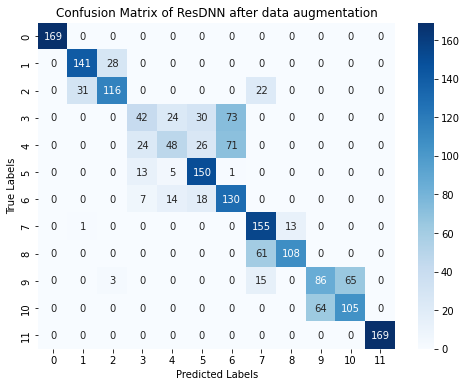

In [14]:
ResDNN_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=ResDNNprediction)
plt.figure(figsize=(8, 6))
sns.heatmap(ResDNN_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of ResDNN after data augmentation')
plt.show()

# Weighted Voting Ensemble

In [15]:
# ====== cấu hình ======
metric = "f1"      # "f1" hoặc "recall"
step = 0.05
N = int(round(1/step))

# ====== danh sách proba của 6 mô hình (ví dụ: xgb, cat, rf, et, dnn, ftt) ======
preds_list = [xgb_preds, cat_preds, rf_preds, lstm_preds, ResDNNpreds, dnn_preds]

best_score = -1.0
best_weights = None

# ====== search weights cho 6 mô hình ======
# w1 = i/N, w2 = j/N, w3 = k/N, w4 = l/N, w5 = m/N, w6 = n/N
for i in range(N + 1):
    for j in range(N + 1 - i):
        for k in range(N + 1 - i - j):
            for l in range(N + 1 - i - j - k):
                for m in range(N + 1 - i - j - k - l):
                    n = N - i - j - k - l - m   # n >= 0, đảm bảo tổng = N

                    w1, w2, w3, w4, w5, w6 = i/N, j/N, k/N, l/N, m/N, n/N

                    proba = (w1*preds_list[0] + w2*preds_list[1] +
                             w3*preds_list[2] + w4*preds_list[3] +
                             w5*preds_list[4] + w6*preds_list[5])

                    pred = proba.argmax(axis=1)

                    if metric == "f1":
                        score = f1_score(y_test, pred, average='macro', zero_division=0)
                    else:
                        score = recall_score(y_test, pred, average='macro', zero_division=0)

                    if score > best_score:
                        best_score = score
                        best_weights = (w1, w2, w3, w4, w5, w6)

print("Best weights (w1..w6):", best_weights, "sum =", sum(best_weights))
print(f"Best {metric} (macro):", best_score)

# ====== AUC macro OVR tại trọng số tốt nhất ======
w1, w2, w3, w4, w5, w6 = best_weights
proba_best = (w1*preds_list[0] + w2*preds_list[1] +
              w3*preds_list[2] + w4*preds_list[3] +
              w5*preds_list[4] + w6*preds_list[5])

try:
    auc_macro_ovr = roc_auc_score(y_test, proba_best, multi_class='ovr', average='macro')
    print("AUC (macro, OVR):", auc_macro_ovr)
except ValueError as e:
    print("AUC không tính được:", e)

Best weights (w1..w6): (0.0, 0.25, 0.35, 0.1, 0.3, 0.0) sum = 1.0
Best f1 (macro): 0.887959774814275
AUC (macro, OVR): 0.9904998657843445


In [16]:
avgs = (
    0.0 * xgb_preds
    + 0.25 * cat_preds
    + 0.35 * rf_preds
    + 0.1 * lstm_preds
    + 0.3 * ResDNNpreds
    + 0.0 * dnn_preds
)

voting_prediction = avgs.argmax(axis=1)
voting_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=voting_prediction)
voting_precision = sklearn.metrics.precision_score(y_true=y_test, y_pred=voting_prediction, average='macro')
voting_f1 = sklearn.metrics.f1_score(y_true=y_test, y_pred=voting_prediction, average='macro')
voting_recall = sklearn.metrics.recall_score(y_true=y_test, y_pred=voting_prediction, average='macro')
voting_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=voting_prediction)


# AUC-ROC calculation
# Convert y_test to binary indicator matrix if it isn't already
if y_test.ndim == 1 or y_test.shape[1] == 1:
    from sklearn.preprocessing import label_binarize
    y_test_binary = label_binarize(y_test, classes=range(avgs.shape[1]))
else:
    y_test_binary = y_test

# Compute the probabilities for each class
voting_probabilities = avgs / avgs.sum(axis=1, keepdims=True)  # Normalize probabilities

# Compute AUC-ROC for each label
auc_roc = sklearn.metrics.roc_auc_score(y_test_binary, voting_probabilities, average='macro', multi_class='ovr')

print("Voting report:")
print("Voting Accuracy:", voting_acc)
print("Voting Precision:", voting_precision)
print("Voting F1:", voting_f1)
print("Voting Recall:", voting_recall)
print("Voting AUC-ROC:", auc_roc)
print("Voting CM:\n", voting_cm)
voting_tpr, voting_fpr = calculate_macro_tpr_fpr(voting_cm)
print(f'Voting Macro-average TPR: {voting_tpr}')
print(f'Voting Macro-average FPR: {voting_fpr}')

Voting report:
Voting Accuracy: 0.8895463510848126
Voting Precision: 0.8913481787516525
Voting F1: 0.887959774814275
Voting Recall: 0.8895463510848126
Voting AUC-ROC: 0.9904998657843445
Voting CM:
 [[169   0   0   0   0   0   0   0   0   0   0   0]
 [  0 169   0   0   0   0   0   0   0   0   0   0]
 [  0   0 169   0   0   0   0   0   0   0   0   0]
 [  0   0   0 168   0   0   1   0   0   0   0   0]
 [  0   0   0   0 169   0   0   0   0   0   0   0]
 [  0   0   0   0   0 169   0   0   0   0   0   0]
 [  0   0   0   0   0   0 169   0   0   0   0   0]
 [  0   1  16   0   0   0   0 138  13   0   1   0]
 [  0   0   0   0   0   0   0  48 121   0   0   0]
 [  0   0   8   0   0   0   0  10   0 107  44   0]
 [  0   0   0   0   0   0   0   0   0  82  87   0]
 [  0   0   0   0   0   0   0   0   0   0   0 169]]
Voting Macro-average TPR: 0.8895463510848126
Voting Macro-average FPR: 0.01004124081047158


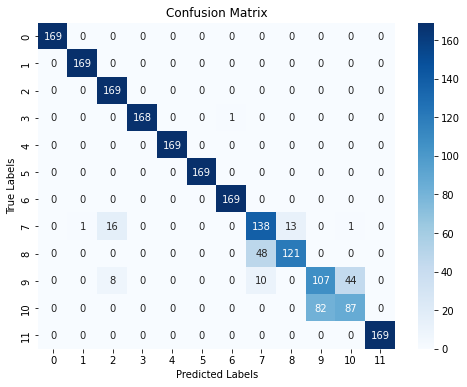

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(voting_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [18]:
# ====== HARD VOTING (đa số phiếu) ======
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix, roc_auc_score

# preds_list: list các ma trận xác suất (N, K) theo đúng thứ tự [xgb, cat, rf, lstm, ResDNN, lgbm]
# y_test: vector nhãn thật (N, )

probas = [xgb_preds, cat_preds, rf_preds, lstm_preds, ResDNNpreds, dnn_preds]
num_models = len(probas)
N, K = probas[0].shape

# 1) Lấy nhãn dự đoán của từng mô hình (hard vote input)
labels_per_model = [p.argmax(axis=1) for p in probas]              # list M phần tử, mỗi phần tử shape (N,)
votes = np.stack(labels_per_model, axis=0)                         # (M, N)

# 2) Hàm hard vote cho 1 mẫu với tie-break bằng tổng xác suất
def hard_vote_with_tiebreak(vote_vec, proba_vecs):
    # vote_vec: (M,)
    # proba_vecs: list dài M, mỗi phần tử là vector xác suất (K,) ứng với cùng 1 mẫu
    counts = np.bincount(vote_vec, minlength=K)
    max_count = counts.max()
    candidates = np.flatnonzero(counts == max_count)               # các lớp đồng phiếu cao nhất

    if len(candidates) == 1:
        return candidates[0]

    # Tie-break: lớp có tổng xác suất cao nhất qua các mô hình
    conf = []
    for c in candidates:
        s = sum(p[c] for p in proba_vecs)                          # tổng độ tự tin cho lớp c
        conf.append(s)
    return candidates[int(np.argmax(conf))]

# 3) Áp hard vote cho toàn bộ N mẫu
y_pred = np.empty(N, dtype=int)
for i in range(N):
    vote_vec = votes[:, i]
    proba_vecs = [p[i] for p in probas]
    y_pred[i] = hard_vote_with_tiebreak(vote_vec, proba_vecs)

# 4) Báo cáo metric
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("Hard Voting report:")
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"F1: {f1}")
print(f"Recall: {rec}")
print("CM:\n", cm)
tpr_macro, fpr_macro = calculate_macro_tpr_fpr(cm)
print(f"Voting Macro-average TPR: {tpr_macro}")
print(f"Voting Macro-average FPR: {fpr_macro}")

Hard Voting report:
Accuracy: 0.8821499013806706
Precision: 0.882206330248839
F1: 0.8803559437083327
Recall: 0.8821499013806707
CM:
 [[169   0   0   0   0   0   0   0   0   0   0   0]
 [  0 169   0   0   0   0   0   0   0   0   0   0]
 [  0   1 168   0   0   0   0   0   0   0   0   0]
 [  0   0   0 168   0   1   0   0   0   0   0   0]
 [  0   0   0   0 168   1   0   0   0   0   0   0]
 [  0   0   0   0   0 169   0   0   0   0   0   0]
 [  0   0   0   0   0   1 168   0   0   0   0   0]
 [  0   1  18   0   0   0   0 125  22   0   3   0]
 [  0   0   0   0   0   0   0  46 123   0   0   0]
 [  0   0   9   0   0   0   0   9   0 108  43   0]
 [  0   0   0   0   0   0   0   0   0  84  85   0]
 [  0   0   0   0   0   0   0   0   0   0   0 169]]
Voting Macro-average TPR: 0.8821499013806707
Voting Macro-average FPR: 0.010713645329029943


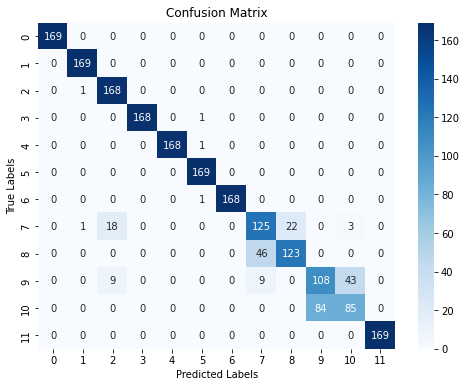

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Mutual Inference

In [20]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# --------- Confidence metrics ----------
def calc_confidence_gbt(p: np.ndarray) -> float:
    """
    Confidence cho model "GBT-like": khoảng cách giữa xác suất lớn nhất và lớn nhì.
    """
    # bảo vệ khi số lớp < 2
    if p.shape[0] < 2:
        return 0.0
    max1 = np.max(p)
    # np.partition an toàn & O(n)
    max2 = np.partition(p, -2)[-2]
    return float(max1 - max2)

def calc_confidence_dl(p: np.ndarray) -> float:
    """
    Confidence cho model DL: 1 - (entropy / log(n_classes))
    """
    k = p.shape[0]
    if k <= 1:
        return 0.0
    # clip để tránh log(0)
    p_safe = np.clip(p, 1e-12, 1.0)
    entropy = -np.sum(p_safe * np.log(p_safe))
    return float(1.0 - entropy / np.log(k))

# --------- Helper: chuẩn hoá input & gom proba ----------
def _ensure_2d(X):
    """
    Ép X về shape (n_samples, n_features) nếu vào 1D.
    """
    X = np.asarray(X)
    if X.ndim == 1:
        X = X[None, :]
    return X

def _stack_proba(models, X):
    """
    Chạy predict_proba trên list model và stack thành array (M, n_samples, n_classes)
    """
    probs = []
    for m in models:
        p = m.predict_proba(X)  # kỳ vọng (n_samples, n_classes)
        p = np.asarray(p, dtype=float)
        # đảm bảo mỗi hàng là phân phối xác suất
        row_sums = p.sum(axis=1, keepdims=True)
        row_sums = np.where(row_sums == 0, 1.0, row_sums)
        p = p / row_sums
        probs.append(p)
    return np.stack(probs, axis=0)  # (M, n_samples, n_classes)

# --------- Ensemble chính (5 GBT + 3 DL) ----------
def mutual_inference_prediction_v2(
    X,
    # đúng thứ tự như bạn yêu cầu:
    lgbm_model, et_model, xgb_model, cat_model, rf_model,
    lstm_model, resdnn_model, dnn_model,
    # pha trộn giữa 2 NHÓM (khác với baseline từng model):
    mix_gbt=0.7,      # phần trăm "quyền lực" của nhóm GBT trong tổng
    mix_dl=0.3,       # phần còn lại cho nhóm DL (tự động chuẩn hoá)
    alpha=0.7, beta=0.7,
    return_details=False,
):
    """
    Ensemble 5 GBT (LGBM, ET, XGB, CAT, RF) + 3 DL (LSTM, ResDNN, DNN)
    theo cơ chế: confidence * agreement + baseline nhóm.

    Tham số:
    - X: (n_samples, n_features) hoặc (n_features,)
    - mix_gbt, mix_dl: trọng số NHÓM (sẽ được chuẩn hoá để mix_gbt + mix_dl = 1)
    - alpha: mức ảnh hưởng của (confidence * agreement) đối với trọng số GBT nội nhóm
    - beta : mức ảnh hưởng tương tự cho DL nội nhóm
    - return_details: trả thêm các chi tiết chẩn đoán

    Trả về:
    - y_pred: (n_samples,)
    - confs : (n_samples,) — max prob sau khi trộn
    - (tuỳ chọn) details: dict chứa weights và probabilities
    """

    X = _ensure_2d(X)

    # Gom nhóm theo yêu cầu
    models_gbt = [lgbm_model, et_model, xgb_model, cat_model, rf_model]   # 5
    models_dl  = [lstm_model, resdnn_model, dnn_model]                    # 3

    # Chuẩn hoá mix nhóm
    group_sum = float(mix_gbt + mix_dl)
    if group_sum <= 0:
        mix_gbt, mix_dl = 0.5, 0.5
    else:
        mix_gbt = float(mix_gbt) / group_sum
        mix_dl  = float(mix_dl)  / group_sum

    # Lấy proba từ tất cả model
    preds_gbt = _stack_proba(models_gbt, X)  # (5, n_samples, n_classes)
    preds_dl  = _stack_proba(models_dl,  X)  # (3, n_samples, n_classes)

    M_g, M_d = preds_gbt.shape[0], preds_dl.shape[0]
    n_samples, n_classes = preds_gbt.shape[1], preds_gbt.shape[2]

    y_preds = np.empty(n_samples, dtype=int)
    confs   = np.empty(n_samples, dtype=float)

    # chi tiết tuỳ chọn
    all_w_gbt, all_w_dl = [], []
    all_p_ens = []

    for i in range(n_samples):
        p_gbt_list = preds_gbt[:, i, :]  # (5, n_classes)
        p_dl_list  = preds_dl[:,  i, :]  # (3, n_classes)

        # Confidence từng model
        c_gbt = np.array([calc_confidence_gbt(p) for p in p_gbt_list])  # (5,)
        c_dl  = np.array([calc_confidence_dl(p)  for p in p_dl_list])   # (3,)

        # Agreement (5 x 3) giữa phân phối xác suất của GBT và DL
        # cosine_similarity nhận (A,B) -> (A_rows, B_rows)
        agree = cosine_similarity(p_gbt_list, p_dl_list)  # (5,3)
        # Có thể clip để tránh âm do sai số số học hiếm hoi
        agree = np.clip(agree, -1.0, 1.0)

        # Trung bình agreement theo cột/hàng
        agree_gbt = agree.mean(axis=1)  # (5,)
        agree_dl  = agree.mean(axis=0)  # (3,)

        # Trọng số nội nhóm (raw)
        # Thay vì baseline riêng từng model, ta dùng "1 - alpha/beta" như một neo nhẹ
        w_gbt_raw = alpha * (c_gbt * agree_gbt) + (1.0 - alpha) * (1.0 / M_g)
        w_dl_raw  = beta  * (c_dl  * agree_dl ) + (1.0 - beta ) * (1.0 / M_d)

        # Chuẩn hoá nội nhóm thành phân phối
        sum_g = w_gbt_raw.sum()
        sum_d = w_dl_raw.sum()
        w_gbt = (w_gbt_raw / sum_g) if sum_g > 0 else np.ones(M_g) / M_g
        w_dl  = (w_dl_raw  / sum_d) if sum_d  > 0 else np.ones(M_d) / M_d

        # Pha trộn cấp NHÓM (đảm bảo xác suất hợp lệ)
        # p_ensemble = mix_gbt * sum_i(w_gbt_i * p_gbt_i) + mix_dl * sum_j(w_dl_j * p_dl_j)
        p_gbt_mix = np.tensordot(w_gbt, p_gbt_list, axes=(0, 0))  # (n_classes,)
        p_dl_mix  = np.tensordot(w_dl,  p_dl_list,  axes=(0, 0))  # (n_classes,)
        p_ens     = mix_gbt * p_gbt_mix + mix_dl * p_dl_mix

        # Chuẩn hoá lần cuối về phân phối (đề phòng sai số)
        s = p_ens.sum()
        if s <= 0:
            p_ens = np.ones(n_classes) / n_classes
        else:
            p_ens = p_ens / s

        y = int(np.argmax(p_ens))
        c = float(np.max(p_ens))

        y_preds[i] = y
        confs[i]   = c

        if return_details:
            all_w_gbt.append(w_gbt.copy())
            all_w_dl.append(w_dl.copy())
            all_p_ens.append(p_ens.copy())

    if return_details:
        details = {
            "weights_gbt": np.array(all_w_gbt),  # (n_samples, 5)
            "weights_dl":  np.array(all_w_dl),   # (n_samples, 3)
            "p_ensemble":  np.array(all_p_ens),  # (n_samples, n_classes)
            "mix_gbt": mix_gbt,
            "mix_dl": mix_dl,
        }
        return y_preds, confs, details
    return y_preds, confs


In [22]:
import numpy as np
from scipy.optimize import differential_evolution
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, log_loss
)
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy

# ---------- Enhanced utils ----------
def _row_normalize(p, epsilon=1e-15):
    """Bảo đảm mỗi hàng là phân phối xác suất hợp lệ."""
    p = np.asarray(p, dtype=np.float64)
    p = np.maximum(p, epsilon)
    row_sums = p.sum(axis=1, keepdims=True)
    row_sums = np.maximum(row_sums, epsilon)
    return p / row_sums

def _softmax(v, temperature=1.0):
    """Softmax với temperature scaling."""
    v = np.asarray(v, dtype=np.float64)
    v = v / temperature
    v = v - v.max()
    ev = np.exp(v)
    return ev / ev.sum()

def _kl_divergence(p, q):
    """Tính KL divergence giữa hai phân phối."""
    p = np.maximum(p, 1e-15)
    q = np.maximum(q, 1e-15)
    return entropy(p, q)

def _js_divergence(p, q):
    """Tính Jensen-Shannon divergence."""
    return jensenshannon(p, q) ** 2

def _confidence_weighted_agreement(preds_list, weights):
    """Tính độ đồng thuận có trọng số dựa trên confidence."""
    N, K = preds_list[0].shape
    agreements = np.zeros(N)
    
    for i in range(N):
        sample_preds = [pred[i] for pred in preds_list]
        confidences = [np.max(pred) for pred in sample_preds]
        
        # Weighted voting based on confidence
        weighted_vote = np.zeros(K)
        for j, (pred, conf, w) in enumerate(zip(sample_preds, confidences, weights)):
            weighted_vote += w * conf * pred
        
        # Agreement measure
        agreements[i] = np.max(weighted_vote) / np.sum(weighted_vote)
    
    return agreements

# ---------- Mutual Inference Core ----------
class MutualInferenceEnsemble:
    def __init__(self, preds_list, model_names, dl_indices, target_dl_weight=0.4):
        self.preds_list = [_row_normalize(pred) for pred in preds_list]
        self.model_names = model_names
        self.dl_indices = dl_indices
        self.target_dl_weight = target_dl_weight
        self.M = len(preds_list)
        self.N, self.K = preds_list[0].shape
        
        # Initialize knowledge matrices for mutual learning
        self.knowledge_matrices = [np.copy(pred) for pred in self.preds_list]
        self.consensus_history = []
        
    def _compute_mutual_influence(self, weights, iteration=0):
        """
        Tính toán ảnh hưởng lẫn nhau giữa các models.
        Mỗi model học hỏi từ consensus của các models khác.
        """
        refined_preds = []
        
        for i, current_pred in enumerate(self.preds_list):
            # Tạo consensus từ các models khác (excluding current model)
            other_indices = [j for j in range(self.M) if j != i]
            other_weights = np.array([weights[j] for j in other_indices])
            other_weights = other_weights / other_weights.sum()  # renormalize
            
            consensus = np.zeros_like(current_pred)
            for j, other_idx in enumerate(other_indices):
                consensus += other_weights[j] * self.knowledge_matrices[other_idx]
            
            # Mutual learning: current model learns from consensus
            learning_rate = 0.3 * (1 - iteration / 10)  # decreasing learning rate
            influence_strength = self._compute_influence_strength(current_pred, consensus)
            
            # Adaptive refinement based on model type
            if i in self.dl_indices:
                # DL models: more adaptive, can learn more from others
                refined_pred = (1 - learning_rate * 1.2) * current_pred + \
                              (learning_rate * 1.2) * consensus * influence_strength.reshape(-1, 1)
            else:
                # Traditional models: more conservative
                refined_pred = (1 - learning_rate * 0.8) * current_pred + \
                              (learning_rate * 0.8) * consensus * influence_strength.reshape(-1, 1)
            
            refined_preds.append(_row_normalize(refined_pred))
        
        return refined_preds
    
    def _compute_influence_strength(self, pred1, pred2):
        """Tính cường độ ảnh hưởng dựa trên similarity và confidence."""
        similarities = []
        for i in range(self.N):
            # JS divergence based similarity
            js_div = _js_divergence(pred1[i], pred2[i])
            similarity = 1 / (1 + js_div)  # convert to similarity
            
            # Confidence factor
            conf1 = np.max(pred1[i])
            conf2 = np.max(pred2[i])
            conf_factor = (conf1 + conf2) / 2
            
            # Combined influence strength
            influence = similarity * conf_factor
            similarities.append(influence)
        
        return np.array(similarities)
    
    def _iterative_mutual_learning(self, weights, max_iterations=5):
        """
        Quá trình học hỏi lẫn nhau qua nhiều iterations.
        """
        self.knowledge_matrices = [np.copy(pred) for pred in self.preds_list]
        
        for iteration in range(max_iterations):
            # Mutual influence step
            refined_preds = self._compute_mutual_influence(weights, iteration)
            
            # Update knowledge matrices
            self.knowledge_matrices = refined_preds
            
            # Compute consensus for monitoring
            consensus = self._compute_weighted_consensus(weights)
            self.consensus_history.append(consensus)
            
            # Early stopping if consensus stabilizes
            if iteration > 0:
                prev_consensus = self.consensus_history[-2]
                consensus_change = np.mean([_js_divergence(consensus[i], prev_consensus[i]) 
                                          for i in range(self.N)])
                if consensus_change < 1e-6:
                    print(f"Mutual learning converged at iteration {iteration}")
                    break
        
        return self.knowledge_matrices
    
    def _compute_weighted_consensus(self, weights):
        """Tính consensus có trọng số từ knowledge matrices."""
        consensus = np.zeros_like(self.knowledge_matrices[0])
        for w, knowledge in zip(weights, self.knowledge_matrices):
            consensus += w * knowledge
        return _row_normalize(consensus)
    
    def _constraint_dl_weights(self, raw_weights):
        """Ràng buộc DL models chiếm đúng target_dl_weight."""
        weights = _softmax(raw_weights)
        
        # Calculate current DL weight
        dl_weight_sum = sum(weights[i] for i in self.dl_indices)
        traditional_indices = [i for i in range(self.M) if i not in self.dl_indices]
        traditional_weight_sum = sum(weights[i] for i in traditional_indices)
        
        # Adjust weights to meet constraint
        if dl_weight_sum > 0 and traditional_weight_sum > 0:
            dl_scale = self.target_dl_weight / dl_weight_sum
            traditional_scale = (1.0 - self.target_dl_weight) / traditional_weight_sum
            
            adjusted_weights = weights.copy()
            for i in self.dl_indices:
                adjusted_weights[i] = weights[i] * dl_scale
            for i in traditional_indices:
                adjusted_weights[i] = weights[i] * traditional_scale
                
            # Ensure normalization
            adjusted_weights = adjusted_weights / adjusted_weights.sum()
            return adjusted_weights
        
        return weights
    
    def mutual_inference_objective(self, raw_weights):
        """
        Mutual Inference objective function.
        Combines prediction quality with mutual learning effectiveness.
        """
        weights = self._constraint_dl_weights(raw_weights)
        
        # Perform iterative mutual learning
        refined_knowledge = self._iterative_mutual_learning(weights)
        
        # Final consensus from refined knowledge
        final_consensus = self._compute_weighted_consensus(weights)
        y_pred = final_consensus.argmax(axis=1)
        
        # Multi-criteria objective
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        
        # Mutual learning quality metrics
        consensus_stability = self._evaluate_consensus_stability()
        model_diversity = self._evaluate_model_diversity(weights)
        learning_effectiveness = self._evaluate_learning_effectiveness()
        
        # Combined objective (weights can be tuned)
        objective = (0.4 * acc +           # Prediction accuracy
                    0.3 * f1 +             # F1 score
                    0.2 * consensus_stability +  # Consensus quality
                    0.1 * (model_diversity + learning_effectiveness) / 2)
        
        return -objective  # minimize negative
    
    def _evaluate_consensus_stability(self):
        """Đánh giá độ ổn định của consensus qua các iterations."""
        if len(self.consensus_history) < 2:
            return 0.5
        
        stabilities = []
        for i in range(1, len(self.consensus_history)):
            prev_consensus = self.consensus_history[i-1]
            curr_consensus = self.consensus_history[i]
            
            stability = 1 - np.mean([_js_divergence(prev_consensus[j], curr_consensus[j]) 
                                   for j in range(self.N)])
            stabilities.append(max(0, stability))
        
        return np.mean(stabilities)
    
    def _evaluate_model_diversity(self, weights):
        """Đánh giá diversity giữa các models."""
        total_diversity = 0
        count = 0
        
        for i in range(self.M):
            for j in range(i+1, self.M):
                pred_i = self.knowledge_matrices[i]
                pred_j = self.knowledge_matrices[j]
                
                diversity = np.mean([_js_divergence(pred_i[k], pred_j[k]) 
                                   for k in range(self.N)])
                weight_factor = weights[i] * weights[j]  # weight by importance
                total_diversity += diversity * weight_factor
                count += weight_factor
        
        return total_diversity / count if count > 0 else 0
    
    def _evaluate_learning_effectiveness(self):
        """Đánh giá hiệu quả của quá trình học hỏi lẫn nhau."""
        if len(self.consensus_history) < 2:
            return 0.5
        
        # Compare initial and final consensus quality
        initial_consensus = self.consensus_history[0]
        final_consensus = self.consensus_history[-1]
        
        # Measure improvement in consensus confidence
        initial_conf = np.mean([np.max(initial_consensus[i]) for i in range(self.N)])
        final_conf = np.mean([np.max(final_consensus[i]) for i in range(self.N)])
        
        improvement = (final_conf - initial_conf) / (initial_conf + 1e-10)
        return max(0, min(1, improvement + 0.5))  # normalize to [0,1]
    
    def optimize_mutual_inference(self):
        """Tối ưu trọng số cho Mutual Inference."""
        bounds = [(-3.0, 3.0)] * self.M
        
        print("🔄 Optimizing Mutual Inference Ensemble...")
        print("🎯 Target: 40% weight for Deep Learning models")
        
        best_result = None
        best_score = float('inf')
        
        # Multiple optimization runs with different strategies
        strategies = ['best1bin', 'rand1exp', 'best2bin']
        
        for i, strategy in enumerate(strategies):
            print(f"📊 Strategy {i+1}/{len(strategies)}: {strategy}")
            
            result = differential_evolution(
                self.mutual_inference_objective,
                bounds=bounds,
                strategy=strategy,
                maxiter=200,
                popsize=15,
                tol=1e-8,
                seed=42 + i,
                polish=True,
                disp=False
            )
            
            if result.fun < best_score:
                best_score = result.fun
                best_result = result
        
        optimal_weights = self._constraint_dl_weights(best_result.x)
        return optimal_weights, best_result

# ---------- Setup and execution ----------
# Prepare data
preds_list = [
    xgb_preds,      # 0
    cat_preds,      # 1  
    rf_preds,       # 2
    ResDNNpreds,    # 3 - DL
    lstm_preds      # 4 - DL
]

model_names = ["XGBoost", "CatBoost", "RandomForest", "LightGBM", "ResDNN", "LSTM"]
dl_indices = [3, 4]  # ResDNN, LSTM indices

# Initialize Mutual Inference Ensemble
mi_ensemble = MutualInferenceEnsemble(
    preds_list=preds_list,
    model_names=model_names, 
    dl_indices=dl_indices,
    target_dl_weight=0.4
)

# Optimize
optimal_weights, optimization_result = mi_ensemble.optimize_mutual_inference()

# Final evaluation with optimized weights
final_knowledge = mi_ensemble._iterative_mutual_learning(optimal_weights, max_iterations=8)
final_consensus = mi_ensemble._compute_weighted_consensus(optimal_weights)
y_pred = final_consensus.argmax(axis=1)

# Compute comprehensive metrics
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
cm = confusion_matrix(y_test, y_pred)

# Additional Mutual Inference specific metrics
consensus_stability = mi_ensemble._evaluate_consensus_stability()
model_diversity = mi_ensemble._evaluate_model_diversity(optimal_weights)
learning_effectiveness = mi_ensemble._evaluate_learning_effectiveness()

# Confidence and uncertainty analysis
confidences = np.array([np.max(final_consensus[i]) for i in range(len(y_test))])
avg_confidence = np.mean(confidences)
prediction_entropy = np.mean([entropy(final_consensus[i] + 1e-15) for i in range(len(y_test))])

# ---------- Comprehensive Report ----------
print("\n" + "="*70)
print("🧠 MUTUAL INFERENCE ENSEMBLE RESULTS 🧠")
print("="*70)

print(f"📋 Models: {', '.join(model_names)}")
print(f"🎯 Deep Learning Weight Target: 40%")

print(f"\n🔧 OPTIMAL WEIGHTS:")
dl_total_weight = 0
traditional_total_weight = 0

for i, (name, weight) in enumerate(zip(model_names, optimal_weights)):
    is_dl = i in dl_indices
    indicator = " 🤖 (Deep Learning)" if is_dl else " 🏛️ (Traditional)"
    print(f"   {name}{indicator}: {weight:.8f}")
    
    if is_dl:
        dl_total_weight += weight
    else:
        traditional_total_weight += weight

print(f"\n📊 WEIGHT DISTRIBUTION:")
print(f"   🤖 Deep Learning Models: {dl_total_weight:.8f} ({dl_total_weight*100:.2f}%)")
print(f"   🏛️ Traditional Models: {traditional_total_weight:.8f} ({traditional_total_weight*100:.2f}%)")

print(f"\n📈 PREDICTION PERFORMANCE:")
print(f"   🎯 Accuracy: {acc:.8f}")
print(f"   🎯 Precision (macro): {precision:.8f}")  
print(f"   🎯 Recall (macro): {recall:.8f}")
print(f"   🎯 F1-Score (macro): {f1:.8f}")

print(f"\n🧠 MUTUAL INFERENCE METRICS:")
print(f"   🔄 Consensus Stability: {consensus_stability:.8f}")
print(f"   🌈 Model Diversity: {model_diversity:.8f}")
print(f"   📚 Learning Effectiveness: {learning_effectiveness:.8f}")
print(f"   🎲 Average Confidence: {avg_confidence:.8f}")
print(f"   🌊 Prediction Entropy: {prediction_entropy:.8f}")

print(f"\n🔍 LEARNING PROCESS:")
print(f"   📖 Iterations Completed: {len(mi_ensemble.consensus_history)}")
print(f"   ⚡ Optimization Score: {-optimization_result.fun:.8f}")

print(f"\n📋 CONFUSION MATRIX:")
print(cm)

print(f"\n💡 MUTUAL INFERENCE INSIGHTS:")
if consensus_stability > 0.7:
    print("   ✅ High consensus stability - models converged well")
else:
    print("   ⚠️ Moderate consensus stability - some disagreement remains")

if model_diversity > 0.3:
    print("   ✅ Good model diversity - complementary strengths maintained")
else:
    print("   ⚠️ Lower model diversity - models may be too similar")

if learning_effectiveness > 0.6:
    print("   ✅ Effective mutual learning - models improved through interaction")
else:
    print("   ⚠️ Limited learning effectiveness - minimal improvement from interaction")

print("="*70)
print("🚀 Mutual Inference Process Complete! 🚀")

🔄 Optimizing Mutual Inference Ensemble...
🎯 Target: 40% weight for Deep Learning models
📊 Strategy 1/3: best1bin
Mutual learning converged at iteration 1
Mutual learning converged at iteration 1
Mutual learning converged at iteration 1
Mutual learning converged at iteration 1
Mutual learning converged at iteration 2
Mutual learning converged at iteration 1
Mutual learning converged at iteration 1
Mutual learning converged at iteration 2
Mutual learning converged at iteration 1
Mutual learning converged at iteration 1
Mutual learning converged at iteration 2
Mutual learning converged at iteration 1
Mutual learning converged at iteration 2
Mutual learning converged at iteration 2
Mutual learning converged at iteration 2
Mutual learning converged at iteration 1
Mutual learning converged at iteration 1
Mutual learning converged at iteration 1
Mutual learning converged at iteration 2


KeyboardInterrupt: 